In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif']=['SimHei']
rcParams['font.sans-serif']=['STHeiti']

In [2]:
df=pd.read_csv('C:/Users/Lenovo/Desktop/house_sales.csv')

In [3]:
print('总记录数：',len(df))
print('字段数量：',len(df.columns))
df.head(5)
df.info()

总记录数： 106118
字段数量： 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   city        106118 non-null  object
 1   address     104452 non-null  object
 2   area        105324 non-null  object
 3   floor       104024 non-null  object
 4   name        105564 non-null  object
 5   price       105564 non-null  object
 6   province    106118 non-null  object
 7   rooms       104036 non-null  object
 8   toward      105240 non-null  object
 9   unit        105564 non-null  object
 10  year        57736 non-null   object
 11  origin_url  105564 non-null  object
dtypes: object(12)
memory usage: 9.7+ MB


In [4]:
# 打印所有列名，查看准确的列名格式
print("当前DataFrame的所有列名：")
print(df.columns.tolist())

当前DataFrame的所有列名：
['city', 'address', 'area', 'floor', 'name', 'price', 'province', 'rooms', 'toward', 'unit', 'year', 'origin_url']


In [5]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


In [6]:
df.isna().sum()

city              0
address        1666
area            794
floor          2094
name            554
price           554
province          0
rooms          2082
toward          878
unit            554
year          48382
origin_url      554
dtype: int64

In [7]:
df.dropna(inplace=True)
print(len(df))

57520


In [8]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [9]:
print(len(df))

28379


In [10]:
df['area']=df['area'].str.replace('㎡','')

In [11]:
df['area']=df['area'].astype(float)

In [12]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46万,安徽,2室1厅,南向,9200元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158万,安徽,4室2厅,南向,13167元/㎡,2012年建,https://hf.esf.fang.com/chushou/3_381138154.htm


In [13]:
df['price']=df['price'].str.replace('万','').astype(float)

In [14]:
df['toward']=df['toward'].astype('category')
df['unit']=df['unit'].str.replace('元/㎡','').astype(float)

In [15]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019年建,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012年建,https://hf.esf.fang.com/chushou/3_381138154.htm


In [16]:
df['year']=df['year'].str.replace('年建','').astype(int)
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,https://hf.esf.fang.com/chushou/3_381138154.htm


In [17]:
df=df[(df['area']<600)&(df['area']>20)]

In [18]:
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
low_price=Q1-1.5*IQR
high_price=Q3+1.5*IQR
df=df[(df['price']<high_price)&(df['price']>low_price)]

In [19]:
df.head()
len(df)

26367

In [20]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,https://hf.esf.fang.com/chushou/3_404372096.htm
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,https://hf.esf.fang.com/chushou/3_398859799.htm
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,https://hf.esf.fang.com/chushou/3_381138154.htm


In [22]:
# --- 1. 地区 district ---
df['district'] = df['address'].str.split('-').str[0]

# 1. 先提取楼层类型，同时处理空值
df['floor_type'] = df['floor'].str.extract(r'^(.+?)\s*\(')[0]
# 把 NaN 替换为 '未知'
df['floor_type'] = df['floor_type'].fillna('未知')

# 2. 安全的分类函数
def floor_classify(x):
    # 先判断是否为字符串（防止残留NaN）
    if not isinstance(x, str):
        return '未知'
    if '低层' in x:
        return '低层'
    elif '中层' in x:
        return '中层'
    elif '高层' in x:
        return '高层'
    elif '超高层' in x:
        return '超高层'
    else:
        return '其他'

df['floor_type'] = df['floor_type'].apply(floor_classify)
# --- 3. 是否直辖市 zxs ---
municipalities = {'北京', '上海', '天津', '重庆'}
df['zxs'] = df['city'].isin(municipalities).astype(int)

# --- 4. 卧室数量 bedrooms、客厅数量 livingrooms ---
df['bedrooms'] = df['rooms'].str.extract(r'(\d+)室').astype(int)
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype(int)

# --- 5. 楼龄 building_age ---
current_year = 2026
df['building_age'] = current_year - df['year']

# --- 6. 价格分段 price_labels ---
bins = [0, 50, 100, 150, 200, float('inf')]
labels = ['低价', '中低价', '中价', '中高价', '高价']
df['price_labels'] = pd.cut(df['price'], bins=bins, labels=labels, right=False)

# 查看新特征效果
print(df[['district', 'floor_type', 'zxs', 'bedrooms', 'livingrooms', 'building_age', 'price_labels']].head())

  district floor_type  zxs  bedrooms  livingrooms  building_age price_labels
0       龙岗         其他    0         3            2            13           中价
2     生态公园         其他    0         3            2             7           中价
4       撮镇         其他    0         2            1             9           低价
6       龙岗         其他    0         2            1             7           低价
8    新亚汽车站         其他    0         4            2            14          中高价


In [23]:
df.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url,district,floor_type,zxs,bedrooms,livingrooms,building_age,price_labels
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,https://hf.esf.fang.com/chushou/3_404230646.htm,龙岗,其他,0,3,2,13,中价
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,https://hf.esf.fang.com/chushou/3_404304901.htm,生态公园,其他,0,3,2,7,中价
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,https://hf.esf.fang.com/chushou/3_404372096.htm,撮镇,其他,0,2,1,9,低价
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,https://hf.esf.fang.com/chushou/3_398859799.htm,龙岗,其他,0,2,1,7,低价
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,https://hf.esf.fang.com/chushou/3_381138154.htm,新亚汽车站,其他,0,4,2,14,中高价


In [26]:
a=df[['price','area','unit','building_age']].corr()

In [27]:
a['price'].sort_values(ascending=False)[1:]

unit            0.740656
area            0.453993
building_age    0.091650
Name: price, dtype: float64

findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif'

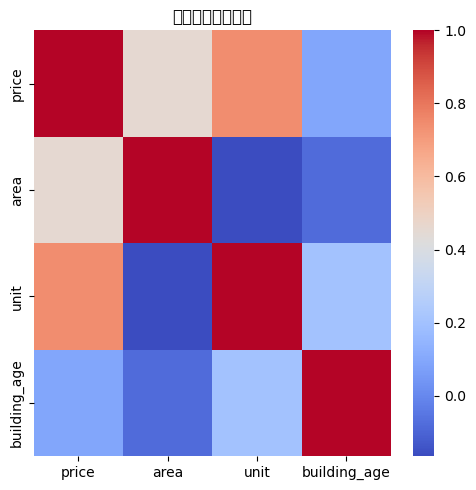

In [34]:
plt.figure(figsize=(5,5))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋相关性热力图')
plt.tight_layout()
plt.show()

In [35]:
df.describe()

,area,price,unit,year,zxs,bedrooms,livingrooms,building_age
count,26367.000000,26367.000000,26367.000000,26367.000000,26367.000000,26367.000000,26367.000000,26367.000000
mean,103.759518,116.784292,11569.063868,2013.094474,0.008685,2.713809,1.848674,12.905526
std,34.036356,60.546962,5778.671039,6.010540,0.092790,0.800999,0.407126,6.010540
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,3.000000
25%,85.095000,71.800000,7570.000000,2011.000000,0.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10294.000000,2015.000000,0.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14139.000000,2017.000000,0.000000,3.000000,2.000000,15.000000
max,470.000000,303.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,50.000000


(array([ 9098., 11317.,  4136.,  1816.]),
 array([  9. ,  82.5, 156. , 229.5, 303. ]),
 <BarContainer object of 4 artists>)

findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif'

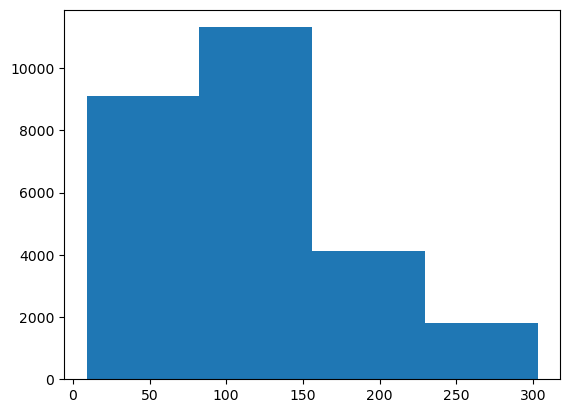

In [36]:
plt.subplot(111)
plt.hist(df['price'],bins=4)

<Axes: xlabel='price', ylabel='Count'>

findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif' not found because none of the following families were found: STHeiti
findfont: Generic family 'sans-serif'

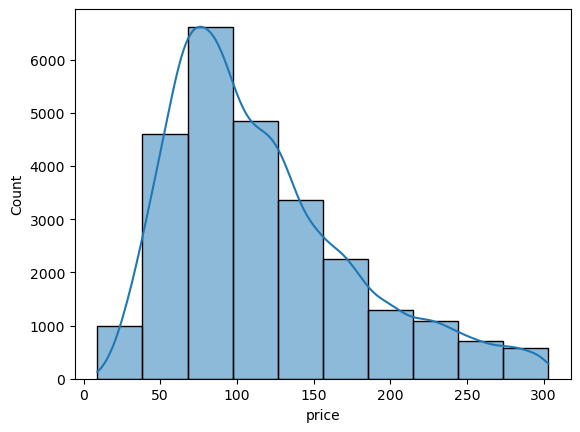

In [37]:
sns.histplot(data=df,x='price',bins=10,kde=True)

In [39]:
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'median',
    'building_age':'mean',
})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19204\906677523.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('toward').agg({


price             unit building_age
              mean  median   median         mean
toward                                          
东北向     114.555333  100.00  12198.0    13.609524
东南向     114.740638  105.00  10863.0    11.893004
东向      109.868341   94.50  11421.0    13.725118
东西向      97.988387   82.00   8936.0    16.419355
北向       92.527907   75.50  11698.0    14.108527
南北向     119.024784  103.80  10000.0    13.060388
南向      114.249023  102.45  10714.0    12.521119
西北向     117.182782  105.00  12290.0    14.315789
西南向     139.292188  138.00  13333.0    14.414062
西向      100.948012   85.00  12500.0    14.360248